# File mosaic plot

It seems quite relevant to be able to create a file mosaic overview plot (like k4dirstat) to see how a file tree is structured. 

The name for such plots is **treemap**. I found several tutorials. However most of them do not describe how to image tree data that is several directories deep. 

The easiest way to get an interactive treemap seems to be plotly: https://statisticsglobe.com/plotly-treemap-python

In [6]:
values = [100, 80, 30, 20, 80, 10]

(np.float64(-1.0), np.float64(101.0), np.float64(-1.0), np.float64(101.0))

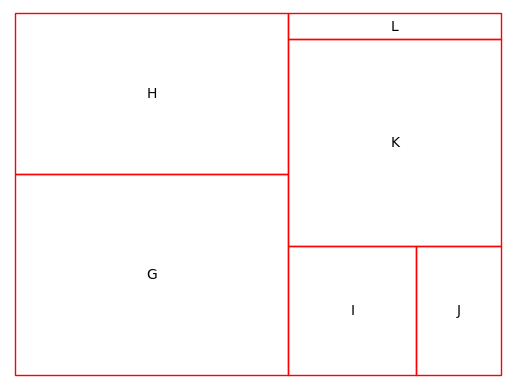

In [8]:
fig, ax = plt.subplots()
sqplot(sizes=values, norm_x=100, norm_y=100, label=list('GHIJKL'), ec='red', fc='none', ax=ax, zorder=1)
#sqplot(sizes=values, norm_x=50, norm_y=50, x0=50, y0=50, label=list('ABCDEF'), ec='green', fc='orange', ax=ax, zorder=2)

ax.set_xlim([-1, 101])
ax.set_ylim([-1, 101])

ax.axis('off')

## FUNCTIONS 

In [1]:
import matplotlib.pyplot as plt
import squarify as sq
import numpy as np

In [2]:
def sqplot(
    sizes,
    x0=0, 
    y0=0,
    norm_x=100,
    norm_y=100,
    color=None,
    label=None,
    value=None,
    ax=None,
    pad=False,
    bar_kwargs=None,
    text_kwargs=None,
    zorder=None, 
    **kwargs
):
    """Plotting with Matplotlib.

    Parameters
    ----------
    sizes
        input for squarify
    norm_x, norm_y
        x and y values for normalization
    color
        color string or list-like (see Matplotlib documentation for details)
    label
        list-like used as label text
    value
        list-like used as value text (in most cases identical with sizes argument)
    ax
        Matplotlib Axes instance
    pad
        draw rectangles with a small gap between them
    bar_kwargs : dict
        keyword arguments passed to matplotlib.Axes.bar
    text_kwargs : dict
        keyword arguments passed to matplotlib.Axes.text
    **kwargs
        Any additional kwargs are merged into `bar_kwargs`. Explicitly provided
        kwargs here will take precedence.

    Returns
    -------
    matplotlib.axes.Axes
        Matplotlib Axes
    """

    import matplotlib.pyplot as plt

    if ax is None:
        ax = plt.gca()

    if color is None:
        import matplotlib.cm
        import random

        cmap = plt.get_cmap()
        color = [cmap(random.random()) for i in range(len(sizes))]

    if bar_kwargs is None:
        bar_kwargs = {}
    if text_kwargs is None:
        text_kwargs = {}
    if len(kwargs) > 0:
        bar_kwargs.update(kwargs)

    normed = sq.normalize_sizes(sizes, norm_x, norm_y)

    if pad:
        rects = sq.padded_squarify(normed, x0, y0, norm_x, norm_y)
    else:
        rects = sq.squarify(normed, x0, y0, norm_x, norm_y)

    x = [rect["x"] for rect in rects]
    y = [rect["y"] for rect in rects]
    dx = [rect["dx"] for rect in rects]
    dy = [rect["dy"] for rect in rects]

    ax.bar(
        x, dy, width=dx, bottom=y, color=color, label=label, align="edge", **bar_kwargs, zorder=zorder
    )

    if value is not None:
        va = "center" if label is None else "top"

        for v, r in zip(value, rects):
            x, y, dx, dy = r["x"], r["y"], r["dx"], r["dy"]
            ax.text(x + dx / 2, y + dy / 2, v, va=va, ha="center", **text_kwargs, zorder=zorder)

    if label is not None:
        va = "center" if value is None else "bottom"
        for l, r in zip(label, rects):
            x, y, dx, dy = r["x"], r["y"], r["dx"], r["dy"]
            ax.text(x + dx / 2, y + dy / 2, l, va=va, ha="center", **text_kwargs, zorder=zorder)

    ax.set_xlim(0, norm_x)
    ax.set_ylim(0, norm_y)
